## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


In [11]:
# Importamos las librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
import kagglehub

In [14]:
path = kagglehub.dataset_download("uciml/adult-census-income")

In [15]:
print("Ruta del dataset: ", path)

Ruta del dataset:  C:\Users\miche\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


In [16]:
dfAdult = pd.read_csv(path + "/adult.csv")

In [17]:
dfAdult.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [18]:
dfAdult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Parte 1. Comprensión del Problema 

El dataset Adult Income contiene información de individuos del censo de Estados Unidos. 

La variable objetivo sera income, ya que esta variable nos indica si el ingreso anual de una persona es <=50K o >50K.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| age | Numérica | Edad del individuo |
| workclass | Categórica | Tipo de empleo |
| fnlwgt | Numérica | Peso final del censo |
| education | Categórica | Nivel educativo |
| education.num | Numérica | Nivel educativo en número |
| marital.status | Categórica | Estado civil |
| occupation | Categórica | Ocupación |
| relationship | Categórica | Relación familiar |
| race | Categórica | Raza |
| sex | Categórica | Sexo |
| capital.gain | Numérica | Ganancia de capital |
| capital.loss | Numérica | Pérdida de capital |
| hours.per.week | Numérica | Horas trabajadas por semana |
| native.country | Categórica | País de origen |
| income | Categórica (objetivo) | Ingreso anual |

## Parte 2. Exploración Inicial

In [20]:
dfAdult.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [21]:
dfAdult["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

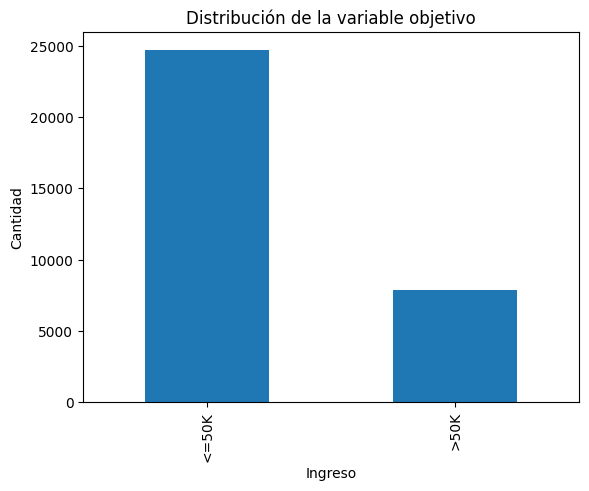

In [22]:
#Graficamos la variable objetivo
dfAdult["income"].value_counts().plot(
    kind="bar"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Ingreso")
plt.ylabel("Cantidad")
plt.show()

In [24]:
# Verificamos valores nulos
dfAdult.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [25]:
# El dataset Adult usa '?' como indicador de valores faltantes entonces revisamos
(dfAdult == "?").sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [29]:
# Tipos de datos
print("Variables numéricas:")
print(dfAdult.select_dtypes(include='number').columns.tolist())

print("\nVariables categóricas:")
print(dfAdult.select_dtypes(include='object').columns.tolist())

Variables numéricas:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Variables categóricas:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


## Parte 3. Correlación e Hipótesis

**Hipótesis iniciales:**
- A mayor nivel educativo (`education.num`), mayor probabilidad de ingresos >50K.
- Las horas trabajadas por semana (`hours.per.week`) pueden influir positivamente.
- El tipo de ocupación (`occupation`) y la clase de trabajo (`workclass`) son factores determinantes.
- La edad (`age`) podría correlacionar con mayor experiencia y por tanto mayores ingresos.

In [35]:
variables_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [36]:
corr = dfAdult[variables_numericas].corr()

In [37]:
corr

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


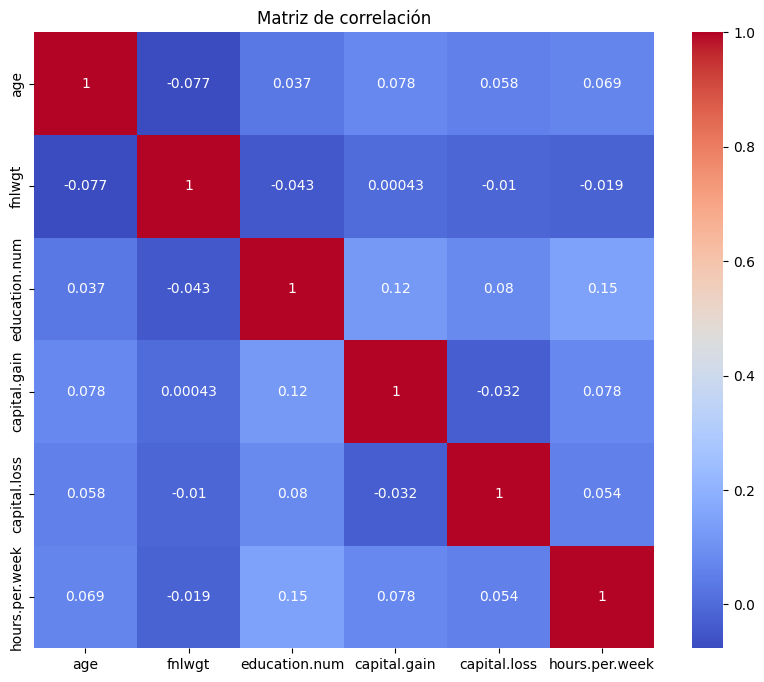

In [38]:
# Matriz de correlación 
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

## Parte 4. Selección de Variables Predictoras y Variable Objetivo

X - Variables que utilizara el modelo

Y - Variables que queremos predecir

In [39]:
columnas = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country"   
]

In [41]:
# Definimos x y
X = dfAdult[columnas]
Y = dfAdult["income"]

In [42]:
print(X.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']


In [44]:
print(Y.name)

income


In [46]:
print("X:", X.shape)
print("Y:", Y.shape)

X: (32561, 14)
Y: (32561,)


## Parte 5. Tratamiento de los Valores

In [47]:
# Reemplazamos "?" por valores nulos
dfAdult.replace("?", np.nan, inplace=True)

In [48]:
# Verificamos los valores nulos 
dfAdult.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [55]:
# Imputamos con la moda en las columnas categóricas
dfAdult["workclass"].fillna(dfAdult["workclass"].mode()[0], inplace=True)
dfAdult["occupation"].fillna(dfAdult["occupation"].mode()[0], inplace=True)
dfAdult["native.country"].fillna(dfAdult["native.country"].mode()[0], inplace=True)

C:\Users\miche\AppData\Local\Temp\ipykernel_19784\2299097591.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfAdult["native.country"].fillna(dfAdult["native.country"].mode()[0], inplace=True)


In [57]:
dfAdult.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Parte 6. Escalado de los datos

Los algoritmos no entienden texto. Se deben convertir las variables categoricas en variables numericas.

In [58]:
dfAdult.select_dtypes(include="object").columns

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')

In [59]:
cat_cols = X.select_dtypes(include="object").columns

In [60]:
cat_cols

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')

In [61]:
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

In [62]:
X.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [63]:
Y = Y.map({
    "<=50K": 0,
    ">50K": 1
})

In [65]:
Y.unique()

array([0, 1])

In [66]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64

## Parte 7. Particionamos los datos

No debemos entrenar y evaluar utilizando los mismos datos.

La recomendación es: 

Entrenamiento 80% Pruebas 20%

In [68]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [72]:
print(f"Registros en entrenamiento: {X_train.shape}")
print(f"Registros en prueba: {X_test.shape}")

Registros en entrenamiento: (26048, 100)
Registros en prueba: (6513, 100)


## Parte 8. Escalado de las variables

Las variables numericas tienen valores distintos. El escalado evita que una variable domine más que otra.

In [73]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(type(X_train))
print(type(X_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [79]:
print(X_train.shape)
print(X_test.shape)

(26048, 100)
(6513, 100)


## Parte 9. Entrenamiento de los datos

In [80]:
modelo = DecisionTreeClassifier(
    random_state = 42
)

In [81]:
modelo.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Parte 10. Evaluamos el modelo

Realizamos predicciones para evaluar el modelo

In [82]:
predicciones = modelo.predict(X_test)

In [86]:
pd.DataFrame({
    "Real": Y_test,
    "Predicción": predicciones 
}).head(20)

,Real,Predicción
14160,0,1
27048,0,0
28868,0,1
5667,0,0
7827,0,0
15382,0,0
4641,0,0
8943,0,0
216,0,0
5121,0,0


## Parte 11. Evaluación del Modelo

El accuracy determina el porcentaje de predicciones correctas realizadas por el modelo.

In [88]:
accuracy = accuracy_score(Y_test, predicciones)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8130


| Accuracy | Interpretación |
|----------|----------------|
| 50% | Adivina |
| 60-70% | Aceptable / Básico |
| 70-80% | Bueno |
| 80-90% | Muy Bueno |
| >90% | Excelente (posible sobreajuste) |

## Parte 12. Importancia de las variables

Analizamos las variables más relevantes para el algoritmo, al realizar las predicciones.

In [90]:
importancias = pd.DataFrame({
    "Variables": X.columns,
    "Importancia": modelo.feature_importances_
})

importancias_sorted = importancias.sort_values(by="Importancia", ascending=False)
importancias_sorted.head(15)

,Variables,Importancia
30,marital.status_Married-civ-spouse,0.199508
1,fnlwgt,0.179329
0,age,0.118312
2,education.num,0.113292
3,capital.gain,0.102557
5,hours.per.week,0.066152
4,capital.loss,0.039610
9,workclass_Private,0.010672
38,occupation_Exec-managerial,0.009562
11,workclass_Self-emp-not-inc,0.008617


In [92]:
print("Variable más importante:")
print(importancias_sorted.iloc[0])

print("\nVariable menos importante:")
print(importancias_sorted.iloc[-1])

Variable más importante:
Variables      marital.status_Married-civ-spouse
Importancia                             0.199508
Name: 30, dtype: object

Variable menos importante:
Variables      native.country_Trinadad&Tobago
Importancia                               0.0
Name: 96, dtype: object


In [103]:
importancias.head(1)

,Variables,Importancia
0,age,0.118312


# Parte 13. Conclusiones

En esta práctica se aplicó un flujo completo de preprocesamiento y entrenamiento de un modelo de Machine Learning utilizando el conjunto de datos Adult Income. Inicialmente se realizó una exploración de los datos para conocer su estructura, tipos de variables y posibles relaciones mediante el análisis de correlación. Posteriormente, se identificó la variable objetivo y las variables predictoras, se trataron los valores faltantes mediante imputación con la moda, se transformaron las variables categóricas a formato numérico y se aplicó un escalado a las variables predictoras.

Una vez preparados los datos, se dividieron en conjuntos de entrenamiento y prueba para entrenar el modelo. Finalmente, se evaluó el desempeño del modelo mediante métricas y se analizó la importancia de las variables para identificar cuáles influyen más en la predicción del nivel de ingresos.

## Preguntas

1. **¿Cuál es la variable objetivo?** `income` 
2. **¿Qué representa dicha variable?** Indica si una persona tiene un ingreso anual mayor a 50,000 dólares (>50K) o menor o igual a 50,000 dólares (<=50K)
3. **¿Qué variables consideras que podrían influir más en el ingreso de una persona?** Con base en el análisis exploratorio y en la importancia de variables obtenida con el modelo, las características con mayor influencia son: `age`, `education`, `education-num`, `occupation`, `hours-per-week`, `capital-gain`, y `marital-status`.
4. **¿Cuántas variables predictoras existen?** Se utilizaron 14 variables predictoras para entrenar el modelo.
5. **¿Por qué fue necesario transformar variables categóricas?** Porque los algoritmos de Machine Learning trabajan con datos numéricos. Las variables categóricas se transformaron mediante **One-Hot Encoding** para que el modelo pudiera procesarlas correctamente.
6. **¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?** 86
7. **¿Existen valores nulos?** No. Los valores faltantes representados con `?` fueron reemplazados por valores nulos y posteriormente imputados con la moda.
8. **¿Qué variables son numéricas?** `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`
9. **¿Qué variables son categóricas?** `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`, `income`
10. **¿Cuántos registros quedaron en entrenamiento?** 26048
11. **¿Cuántos registros quedaron en prueba?** 6513
12. **¿Por qué no debemos entrenar utilizando todos los datos?** Porque es necesario reservar un conjunto de prueba para evaluar el desempeño del modelo con datos que no ha visto previamente.
13. **¿Cuál fue el Accuracy obtenido?** 0.8130
14. **¿Consideras que el resultado es adecuado?** Si, ya que el Accuracy obtenido es superior al 80%, y puede considerarse un buen resultado para este problema de clasificación, ya que el modelo logró predecir correctamente la mayoría de los casos.
15. **¿Qué factores podrían afectar el desempeño del modelo?** La calidad de los datos, el tratamiento de valores faltantes, el desbalance entre clases, la selección de variables y la cantidad de datos disponibles para el entrenamiento.
16. **¿Cuál fue la variable más importante?** `marital.status`
17. **¿Cuál fue la menos importante?** `native.country`
18. **¿Coinciden los resultados con tus hipótesis iniciales?** Sí. Las variables identificadas como más importantes por el modelo coinciden con la hipótesis inicial, ya que factores como la educación, la edad, las horas trabajadas y las ganancias de capital influyen significativamente en el nivel de ingresos de una persona.
19. **¿Qué variables aportan más información al modelo?** Las variables con mayor aporte son aquellas que presentan una mayor importancia en el modelo, generalmente `capital-gain`, `education-num`, `age`, `hours-per-week` y algunas categorías relacionadas con la ocupación y el estado civil.
